In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/machine learning/praktikum/praktikum3"

In [3]:
import pandas as pd

# Membaca dataset bike sharing
df = pd.read_csv(path + '/data/day.csv', sep=',')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
df1 = df[['season', 'yr', 'mnth', 'holiday', 'weekday',
          'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']].copy()
df1.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [8]:
from sklearn.model_selection import train_test_split

# Tentukan variabel dependen dan independen
y = df1['cnt']
X = df1[['season', 'yr', 'mnth', 'holiday', 'weekday',
         'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']]

# Bagi data menjadi training dan testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data training :", len(X_train))
print("Jumlah data testing  :", len(X_test))

Jumlah data training : 584
Jumlah data testing  : 147


In [9]:
from sklearn.linear_model import LinearRegression

# Buat dan latih model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Prediksi data uji
y_pred = model.predict(X_test)

# Evaluasi model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Koefisien tiap variabel:")
for nama, coef in zip(X.columns, model.coef_):
    print(f"  {nama:12s} : {coef:.3f}")

print("\nIntersep:", model.intercept_)
print(f"R² (test): {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

Koefisien tiap variabel:
  season       : 524.723
  yr           : 2023.998
  mnth         : -38.445
  holiday      : -391.551
  weekday      : 72.937
  workingday   : 160.805
  weathersit   : -632.856
  temp         : 2097.248
  atemp        : 3488.042
  hum          : -865.439
  windspeed    : -2080.540

Intersep: 1248.3209284778172
R² (test): 0.828
MAE: 617.39
MSE: 691035.01
RMSE: 831.29


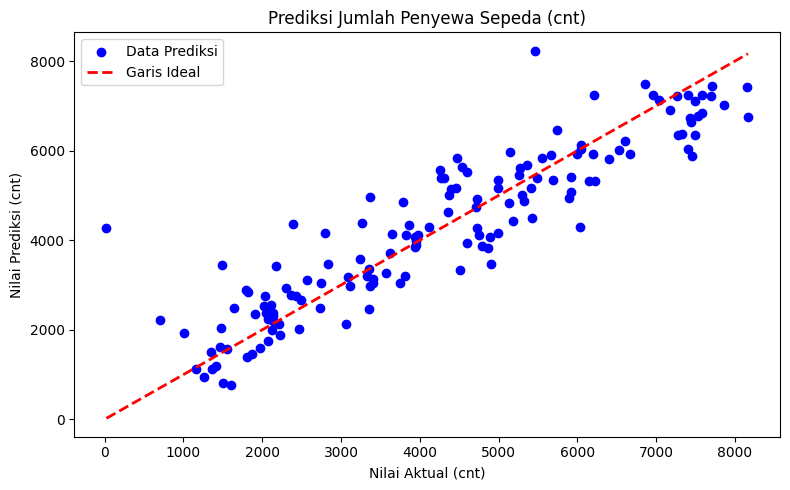

In [11]:
import matplotlib.pyplot as plt

# Scatter plot hasil aktual vs prediksi
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color="blue", label="Data Prediksi")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label="Garis Ideal")
plt.xlabel("Nilai Aktual (cnt)")
plt.ylabel("Nilai Prediksi (cnt)")
plt.title("Prediksi Jumlah Penyewa Sepeda (cnt)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
hasil = pd.DataFrame({
    "Cnt Aktual": y_test.to_numpy(),
    "Cnt Prediksi": y_pred
})

# Hitung selisih dan akurasi
hasil["Selisih (cnt)"] = hasil["Cnt Prediksi"] - hasil["Cnt Aktual"]
denom = hasil["Cnt Aktual"].replace(0, np.nan)
hasil["Akurasi (%)"] = (1 - (hasil["Selisih (cnt)"].abs() / denom)).clip(lower=0, upper=1) * 100

hasil.head(10)

,Cnt Aktual,Cnt Prediksi,Selisih (cnt),Akurasi (%)
0,6606,6220.416612,-385.583388,94.163134
1,1550,1571.605763,21.605763,98.606080
2,3747,3043.967028,-703.032972,81.237444
3,6041,4307.202484,-1733.797516,71.299495
4,7538,6765.659072,-772.340928,89.754034
5,7264,7231.536106,-32.463894,99.553085
6,1605,774.904147,-830.095853,48.280632
7,2209,2139.606601,-69.393399,96.858606
8,7499,7112.745605,-386.254395,94.849255
9,5743,6458.992169,715.992169,87.532785


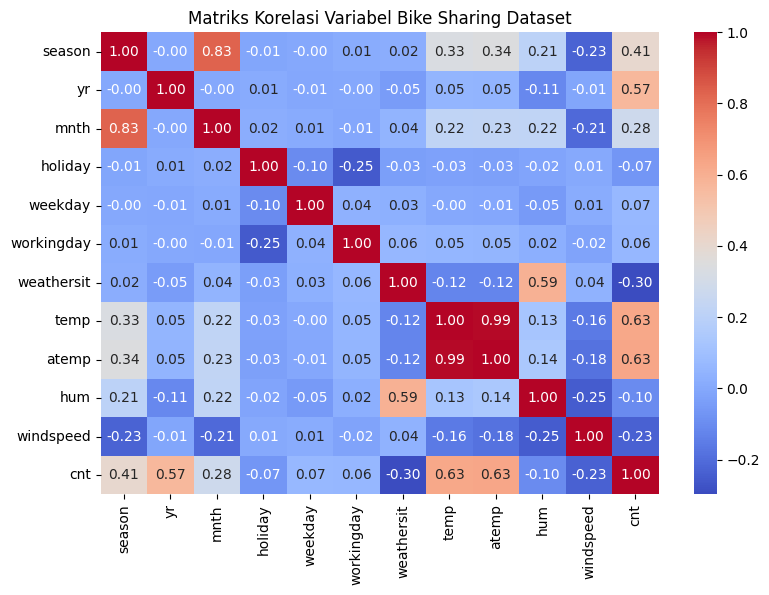

In [13]:
import seaborn as sns

plt.figure(figsize=(9, 6))
sns.heatmap(df1.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriks Korelasi Variabel Bike Sharing Dataset")
plt.show()

In [15]:
hasil.to_csv(path + '/data/hasil_prediksi_bikesharing.csv', index=False)
print("✅ File hasil_prediksi_bikesharing.csv telah disimpan di Google Drive kamu!")

✅ File hasil_prediksi_bikesharing.csv telah disimpan di Google Drive kamu!
